# 05 – Finalisasi, Visualisasi Slide & Review
**Proyek Capstone – Sistem Deteksi Anomali Kualitas Udara**  
**Kelompok Aeris | PENS 2026**  
**PIC: Linda Anggara Wati – Data, EDA, Feature Engineering & ML**

---
**Minggu 5 | 25 Mei – 31 Mei 2026**  

**Checklist Minggu 5 (Linda):**
- [x] Finalisasi tabel rekap 15 model
- [x] Viz slide 1: Distribusi ISPU per segmen (boxplot)
- [x] Viz slide 2: Heatmap korelasi fitur vs polutan
- [x] Viz slide 3: Tabel model terbaik per kombinasi
- [x] Viz slide 4: Perbandingan MAE/RMSE/R2 antar model
- [x] Viz slide 5: Ringkasan temuan utama
- [x] Tulis bagian ML/PyCaret untuk README.md

**Output:** `reports/slide_viz/` + `reports/readme_ml_section.md`

## 1. Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(ROOT)
print(f"Working directory: {os.getcwd()}")

os.makedirs("reports/slide_viz", exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"]  = 11

POLUTAN = ["pm25", "pm10", "co", "no2", "o3"]
SEGMEN  = ["PAGI", "SIANG", "SORE_MALAM"]

model_short = {
    "BayesianRidge"        : "BayesianRidge",
    "LGBMRegressor"        : "LightGBM",
    "ExtraTreesRegressor"  : "ExtraTrees",
    "CatBoostRegressor"    : "CatBoost",
    "RandomForestRegressor": "RandomForest",
    "XGBRegressor"         : "XGBoost",
    "LinearRegression"     : "LinearReg",
}

print("Library loaded")

Working directory: D:\mlops\aeris-air-quality
Library loaded


In [2]:
# Load data
df       = pd.read_csv("data/processed/surabaya_processed.csv",
                        parse_dates=["time"])
df_rekap = pd.read_csv("reports/rekap_15_model.csv")

# Tentukan kolom metrik yang tersedia
if "mae_final" in df_rekap.columns:
    mae_col, rmse_col, r2_col = "mae_final", "rmse_final", "r2_final"
else:
    mae_col, rmse_col, r2_col = "mae_tuned", "rmse_tuned", "r2_tuned"

print(f"Data processed : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Rekap 15 model : {df_rekap.shape[0]} kombinasi")
print(f"Kolom metrik   : {mae_col}, {rmse_col}, {r2_col}")

Data processed : 3,696 baris x 69 kolom
Rekap 15 model : 15 kombinasi
Kolom metrik   : mae_final, rmse_final, r2_final


## 2. Viz Slide 1 – Distribusi ISPU per Segmen Waktu

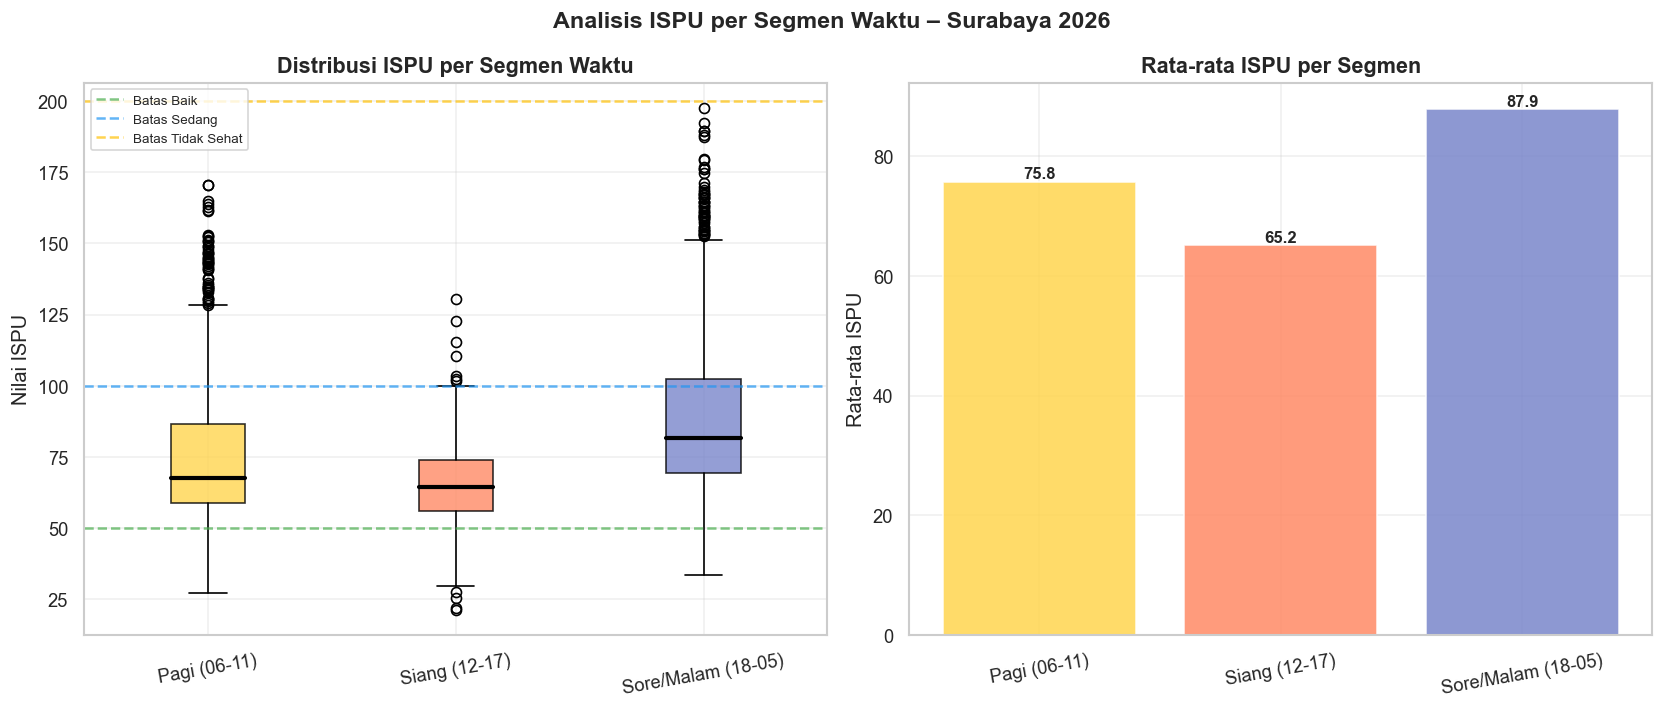

Disimpan -> reports/slide_viz/slide1_ispu_per_segmen.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

seg_colors = {"PAGI": "#FFD54F", "SIANG": "#FF8A65", "SORE_MALAM": "#7986CB"}
seg_labels = {
    "PAGI"      : "Pagi (06-11)",
    "SIANG"     : "Siang (12-17)",
    "SORE_MALAM": "Sore/Malam (18-05)"
}

# Boxplot ISPU per segmen
data_seg = [df[df["time_segment"] == s]["ispu_final"].dropna()
            for s in SEGMEN]
bp = axes[0].boxplot(
    data_seg,
    labels      = [seg_labels[s] for s in SEGMEN],
    patch_artist= True,
    medianprops = dict(color="black", linewidth=2.5)
)
for patch, seg in zip(bp["boxes"], SEGMEN):
    patch.set_facecolor(seg_colors[seg])
    patch.set_alpha(0.8)

for val, label, color in [
    (50,  "Baik",        "#4CAF50"),
    (100, "Sedang",      "#2196F3"),
    (200, "Tidak Sehat", "#FFC107"),
]:
    axes[0].axhline(val, color=color, ls="--",
                    lw=1.5, alpha=0.7, label=f"Batas {label}")

axes[0].set_title("Distribusi ISPU per Segmen Waktu",
                  fontweight="bold", fontsize=13)
axes[0].set_ylabel("Nilai ISPU")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=10)
axes[0].grid(True, alpha=0.3)

# Bar rata-rata ISPU per segmen
avg_ispu = df.groupby("time_segment")["ispu_final"].mean().reindex(SEGMEN)
bars = axes[1].bar(
    [seg_labels[s] for s in SEGMEN],
    avg_ispu.values,
    color=[seg_colors[s] for s in SEGMEN],
    edgecolor="white", alpha=0.85
)
for bar, val in zip(bars, avg_ispu.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{val:.1f}",
        ha="center", fontweight="bold", fontsize=10
    )
axes[1].set_title("Rata-rata ISPU per Segmen",
                  fontweight="bold", fontsize=13)
axes[1].set_ylabel("Rata-rata ISPU")
axes[1].tick_params(axis="x", rotation=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Analisis ISPU per Segmen Waktu – Surabaya 2026",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide1_ispu_per_segmen.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/slide1_ispu_per_segmen.png")

## 3. Viz Slide 2 – Heatmap Korelasi Fitur vs Polutan

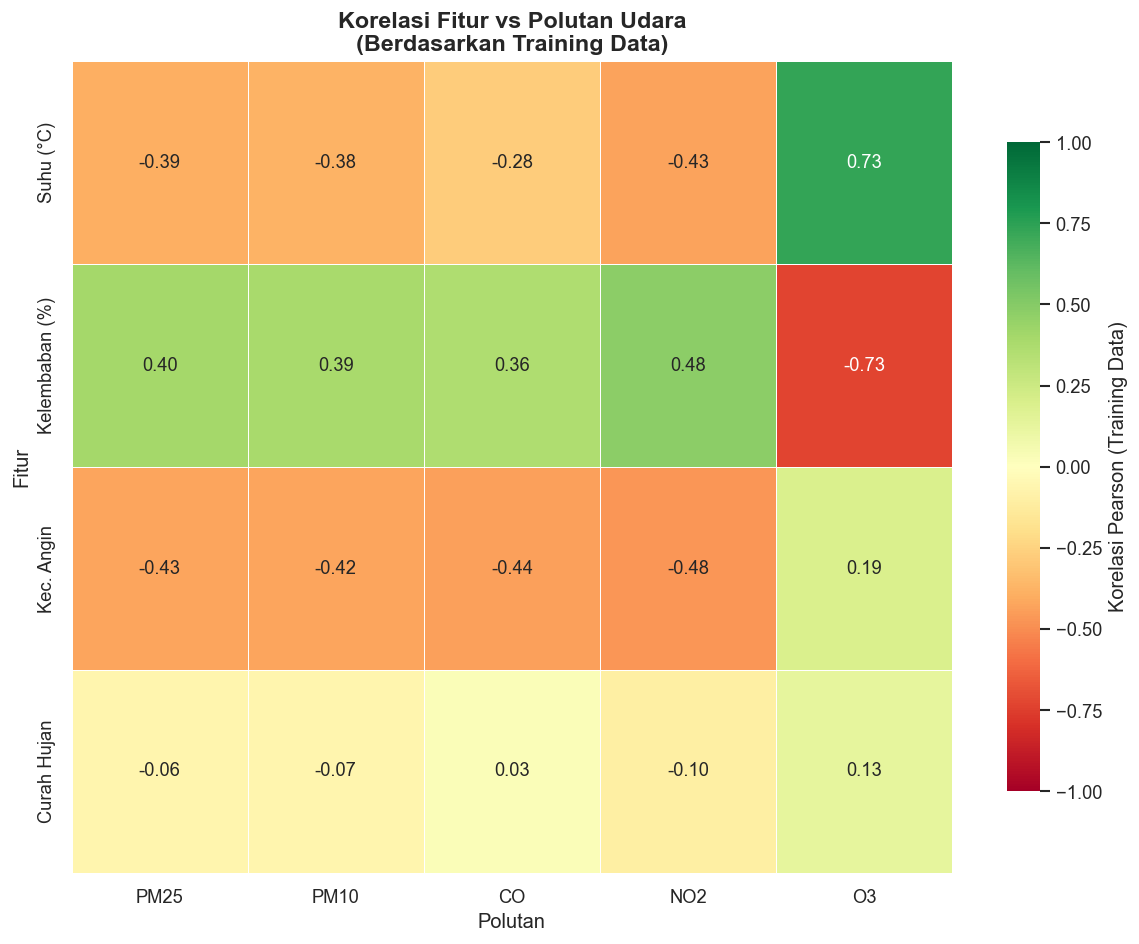

Disimpan -> reports/slide_viz/slide2_korelasi_fitur_polutan.png


In [4]:
# ============================================
# SLIDE 2 - HEATMAP KORELASI (HANYAR DARI TRAINING DATA)
# ============================================

# Load training data (bukan seluruh dataset)
train = pd.read_csv("data/processed/train.csv", parse_dates=["time"])

meteo_feats = [
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "precipitation",
    "hour", "is_weekend"
]
lag_feats = [f"{p}_lag_1h" for p in POLUTAN]
all_feats = meteo_feats + lag_feats

# Korelasi hanya dari TRAINING DATA (tidak bocor!)
cols_corr = [c for c in all_feats + POLUTAN if c in train.columns]
corr_full = train[cols_corr].corr()

feat_cols = [c for c in all_feats  if c in corr_full.columns]
pol_cols  = [c for c in POLUTAN    if c in corr_full.columns]
corr_sub  = corr_full.loc[feat_cols, pol_cols]

label_map = {
    "temperature_2m"   : "Suhu (°C)",
    "relative_humidity": "Kelembaban (%)",
    "wind_speed_10m"   : "Kec. Angin",
    "precipitation"    : "Curah Hujan",
    "hour"             : "Jam",
    "is_weekend"       : "Weekend",
    "pm25_lag_1h"      : "PM2.5 (t-1h)",
    "pm10_lag_1h"      : "PM10 (t-1h)",
    "co_lag_1h"        : "CO (t-1h)",
    "no2_lag_1h"       : "NO2 (t-1h)",
    "o3_lag_1h"        : "O3 (t-1h)",
}
corr_sub.index   = [label_map.get(c, c) for c in corr_sub.index]
corr_sub.columns = [c.upper() for c in corr_sub.columns]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_sub, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Korelasi Pearson (Training Data)", "shrink": 0.8}
)
ax.set_title("Korelasi Fitur vs Polutan Udara\n(Berdasarkan Training Data)",
             fontweight="bold", fontsize=14)
ax.set_xlabel("Polutan")
ax.set_ylabel("Fitur")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide2_korelasi_fitur_polutan.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/slide2_korelasi_fitur_polutan.png")

## 4. Viz Slide 3 – Tabel Model Terbaik per Kombinasi

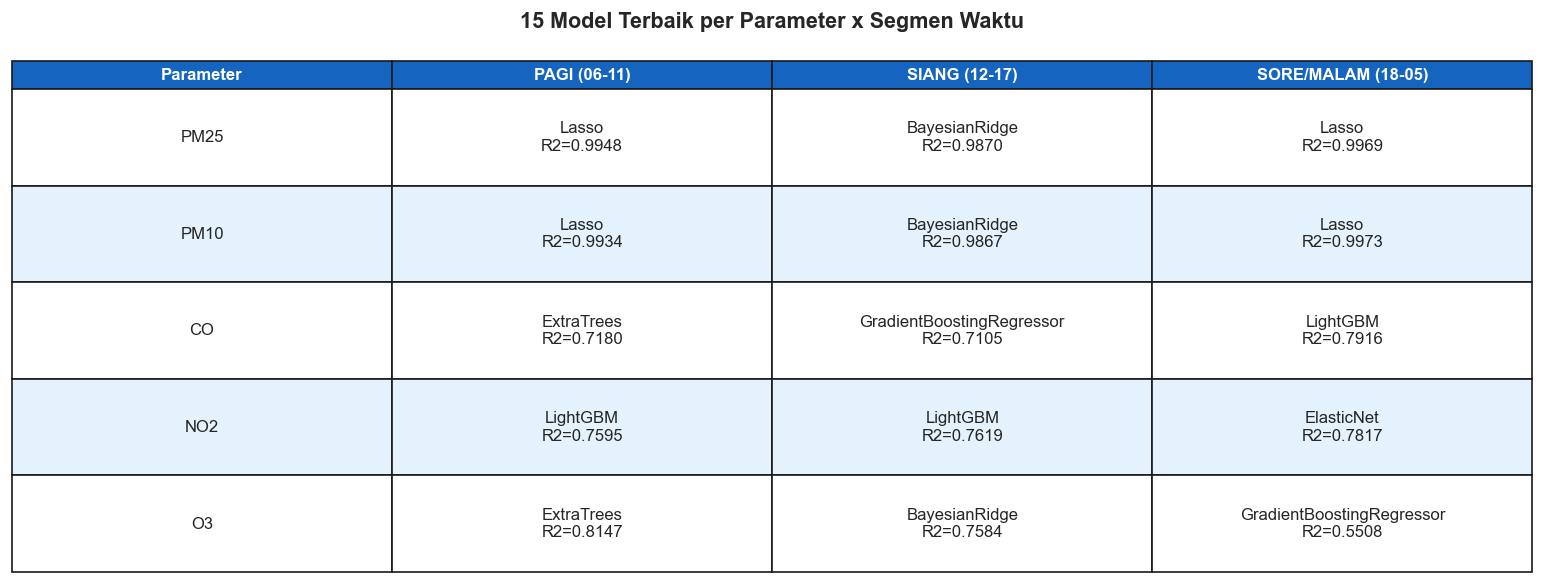

Disimpan -> reports/slide_viz/slide3_tabel_15_model.png


In [5]:
pivot_model = df_rekap.pivot(
    index="polutan", columns="segmen", values="model_terbaik"
)[["PAGI", "SIANG", "SORE_MALAM"]]

pivot_r2 = df_rekap.pivot(
    index="polutan", columns="segmen", values=r2_col
)[["PAGI", "SIANG", "SORE_MALAM"]].round(4)

fig, ax = plt.subplots(figsize=(13, 5))
ax.axis("off")

col_headers = ["Parameter", "PAGI (06-11)", "SIANG (12-17)", "SORE/MALAM (18-05)"]
rows = []
for pol in ["PM25", "PM10", "CO", "NO2", "O3"]:
    row = [pol]
    for seg in ["PAGI", "SIANG", "SORE_MALAM"]:
        try:
            m = pivot_model.loc[pol, seg]
            r = pivot_r2.loc[pol, seg]
            row.append(f"{model_short.get(m, m)}\nR2={r:.4f}")
        except:
            row.append("N/A")
    rows.append(row)

table = ax.table(
    cellText  = rows,
    colLabels = col_headers,
    cellLoc   = "center",
    loc       = "center",
    bbox      = [0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(10)

for j in range(len(col_headers)):
    table[0, j].set_facecolor("#1565C0")
    table[0, j].set_text_props(color="white", fontweight="bold")

for i in range(1, len(rows) + 1):
    for j in range(len(col_headers)):
        if i % 2 == 0:
            table[i, j].set_facecolor("#E3F2FD")
        table[i, j].set_height(0.15)

ax.set_title("15 Model Terbaik per Parameter x Segmen Waktu",
             fontweight="bold", fontsize=13, pad=20)
plt.tight_layout()
plt.savefig("reports/slide_viz/slide3_tabel_15_model.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/slide3_tabel_15_model.png")

## 5. Viz Slide 4 – Perbandingan MAE/RMSE/R2 per Parameter

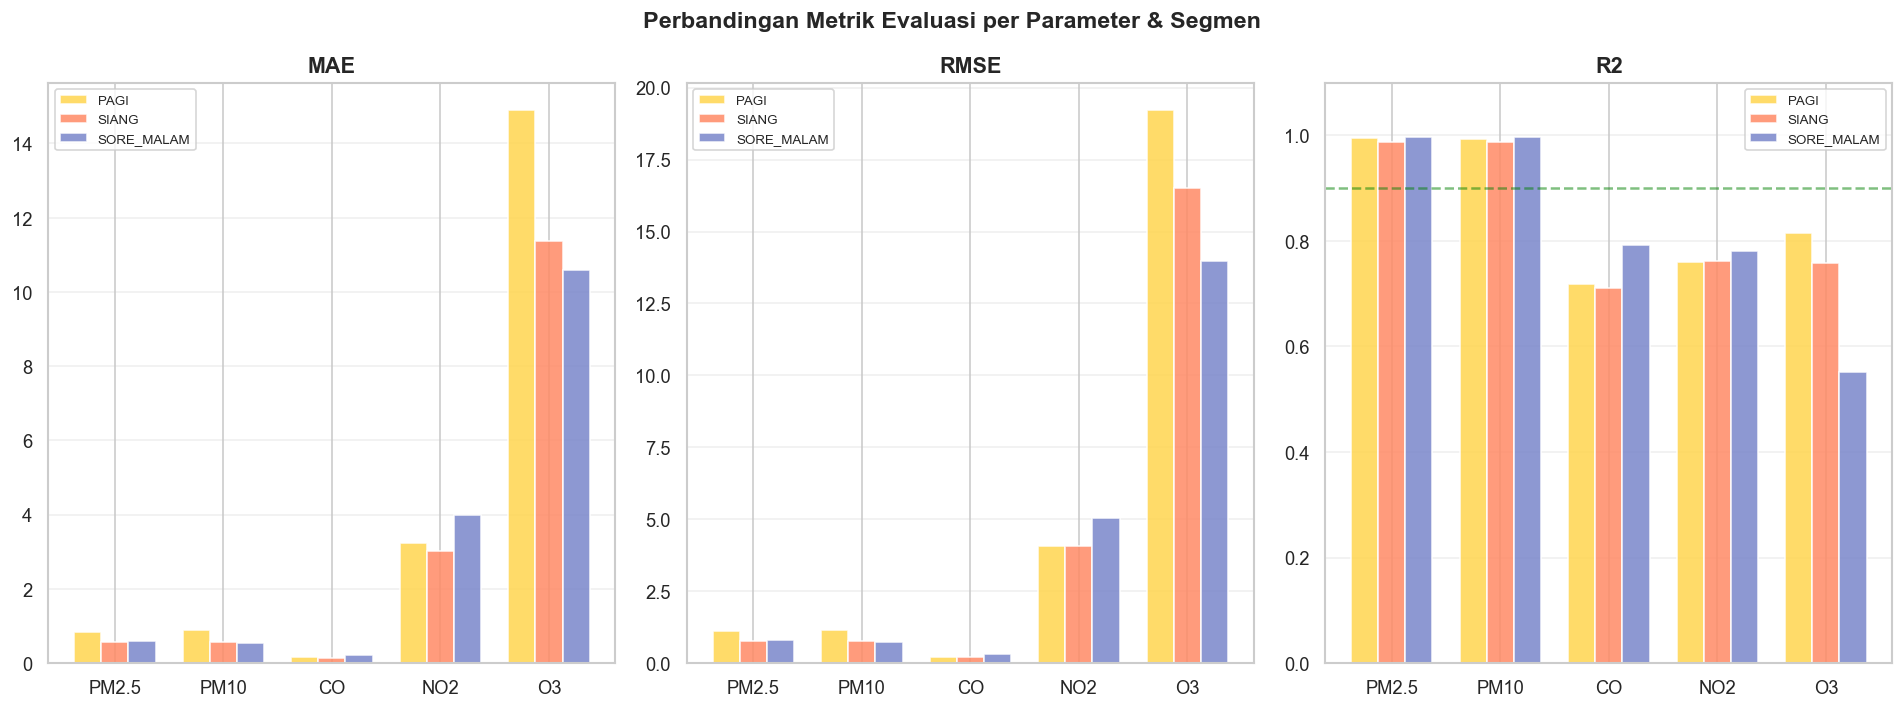

Disimpan -> reports/slide_viz/slide4_metrik_evaluasi.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

pol_labels = {
    "PM25": "PM2.5", "PM10": "PM10",
    "CO": "CO", "NO2": "NO2", "O3": "O3"
}
seg_colors = {"PAGI": "#FFD54F", "SIANG": "#FF8A65", "SORE_MALAM": "#7986CB"}
x          = np.arange(5)
width      = 0.25
pol_order  = ["PM25", "PM10", "CO", "NO2", "O3"]

for ax, metric, title in zip(
    axes,
    [mae_col, rmse_col, r2_col],
    ["MAE", "RMSE", "R2"]
):
    for i, seg in enumerate(SEGMEN):
        vals = []
        for pol in pol_order:
            sub = df_rekap[
                (df_rekap["polutan"] == pol) &
                (df_rekap["segmen"]  == seg)
            ]
            vals.append(sub[metric].values[0] if len(sub) > 0 else 0)

        ax.bar(x + i * width, vals, width,
               label=seg, color=seg_colors[seg],
               edgecolor="white", alpha=0.85)

    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels([pol_labels[p] for p in pol_order])
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    if title == "R2":
        ax.set_ylim(0, 1.1)
        ax.axhline(0.9, color="green", ls="--",
                   lw=1.5, alpha=0.5, label="R2=0.9")

plt.suptitle("Perbandingan Metrik Evaluasi per Parameter & Segmen",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide4_metrik_evaluasi.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/slide4_metrik_evaluasi.png")

## 6. Viz Slide 5 – Ringkasan Temuan Utama

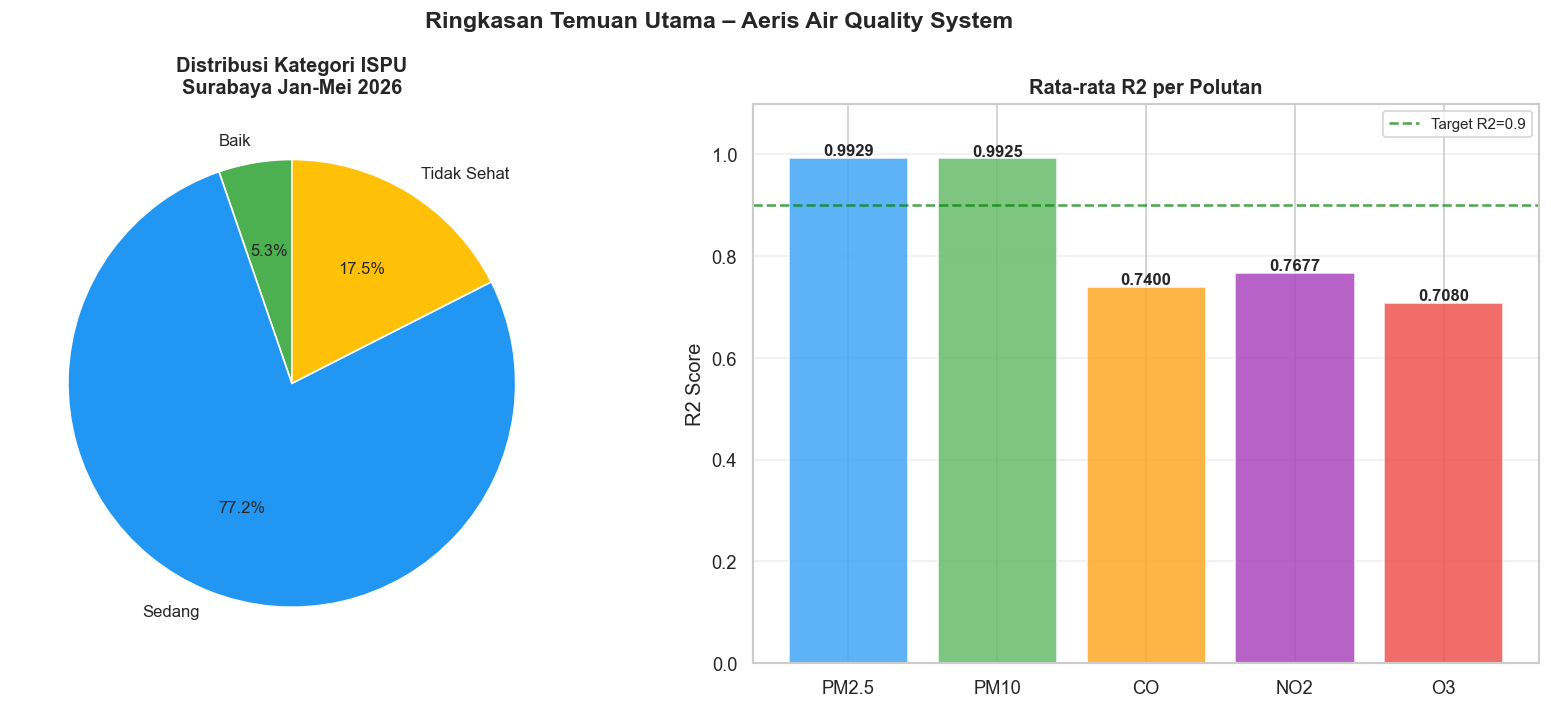

Disimpan -> reports/slide_viz/slide5_ringkasan.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart distribusi kategori ISPU
warna_ispu = {
    "Baik"              : "#4CAF50",
    "Sedang"            : "#2196F3",
    "Tidak Sehat"       : "#FFC107",
    "Sangat Tidak Sehat": "#F44336",
    "Berbahaya"         : "#212121",
}
urutan    = ["Baik", "Sedang", "Tidak Sehat",
             "Sangat Tidak Sehat", "Berbahaya"]
cat_count = df["ispu_category"].value_counts().reindex(urutan, fill_value=0)
valid     = cat_count[cat_count > 0]

axes[0].pie(
    valid.values,
    labels    = valid.index,
    colors    = [warna_ispu[k] for k in valid.index],
    autopct   = "%1.1f%%",
    startangle= 90,
    textprops = {"fontsize": 10}
)
axes[0].set_title("Distribusi Kategori ISPU\nSurabaya Jan-Mei 2026",
                  fontweight="bold", fontsize=12)

# Bar R² rata-rata per polutan
r2_avg     = df_rekap.groupby("polutan")[r2_col].mean().reindex(pol_order)
pol_colors = ["#42A5F5", "#66BB6A", "#FFA726", "#AB47BC", "#EF5350"]
bars = axes[1].bar(
    [pol_labels[p] for p in pol_order],
    r2_avg.values,
    color=pol_colors, edgecolor="white", alpha=0.85
)
for bar, val in zip(bars, r2_avg.values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", fontweight="bold", fontsize=10
    )
axes[1].axhline(0.9, color="green", ls="--",
                lw=1.5, alpha=0.7, label="Target R2=0.9")
axes[1].set_title("Rata-rata R2 per Polutan",
                  fontweight="bold", fontsize=12)
axes[1].set_ylabel("R2 Score")
axes[1].set_ylim(0, 1.1)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)

plt.suptitle("Ringkasan Temuan Utama – Aeris Air Quality System",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/slide5_ringkasan.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/slide5_ringkasan.png")

## 6b. Evaluasi Lanjutan – Learning Curve & Residual Plot (Untuk Rubrik Capstone)

EVALUASI LANJUTAN - LEARNING CURVE & RESIDUAL PLOT



Menganalisis model terbaik: PM25 - PAGI

1. Menghitung Learning Curve...


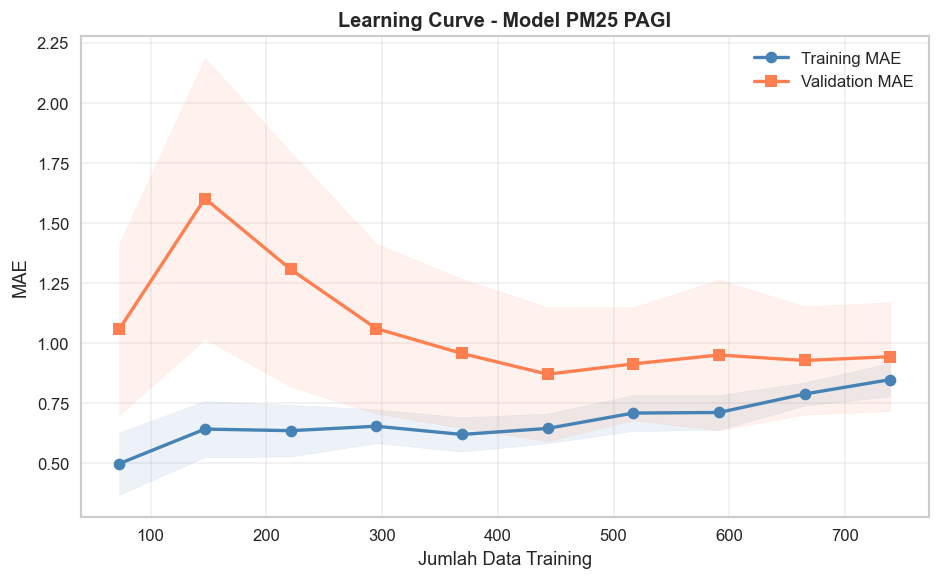

Disimpan -> reports/slide_viz/learning_curve.png

2. Menghitung Residual Plot...


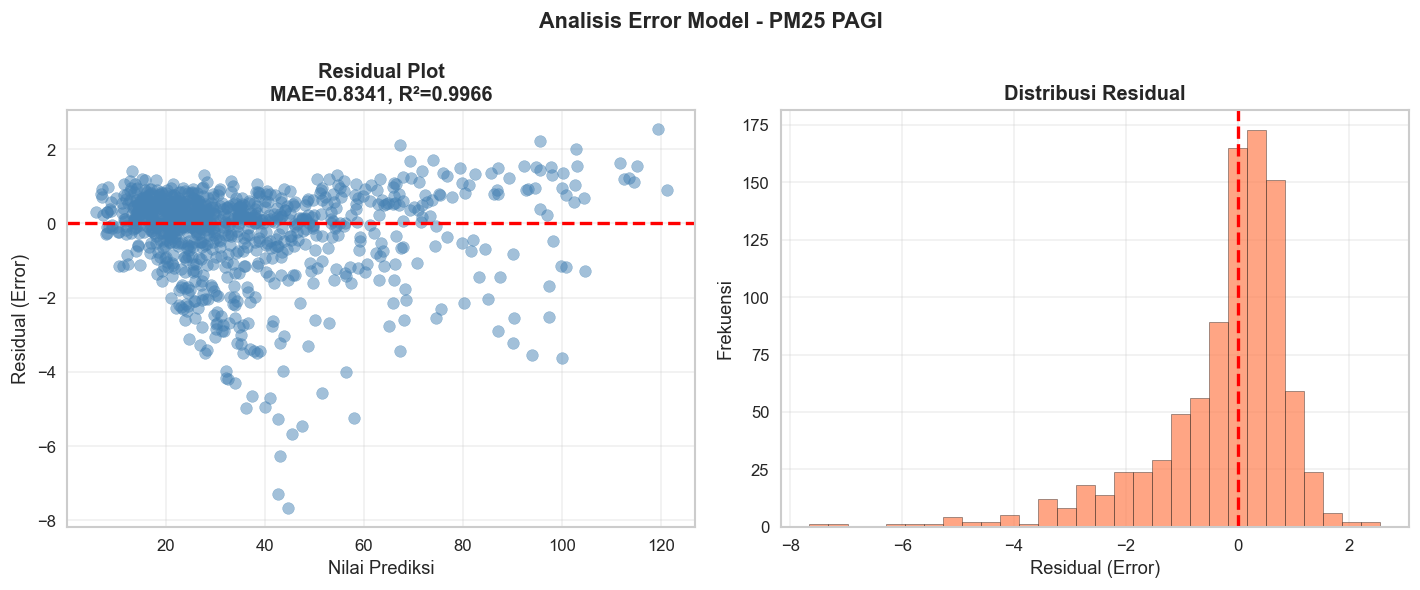

Disimpan -> reports/slide_viz/residual_plot.png

INTERPRETASI HASIL EVALUASI
✅ Model TIDAK overfitting (gap MAE = -0.0954)

Statistik Residual:
  Mean residual  : -0.2349 (idealnya mendekati 0)
  Std residual   : 1.2385
  Residual range : [-7.6592, 2.5517]
  ⚠️ Residual bias (model cenderung over/under predict)

📌 Kesimpulan: Model siap digunakan untuk prediksi polutan udara.


In [8]:
print("=" * 55)
print("EVALUASI LANJUTAN - LEARNING CURVE & RESIDUAL PLOT")
print("=" * 55)

from pycaret.regression import load_model
from sklearn.model_selection import learning_curve
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Pilih model terbaik (contoh: PM25 PAGI karena R2 tertinggi)
best_model_path = "models/pm25_pagi_best"
best_polutan = "PM25"
best_segmen = "PAGI"

print(f"\nMenganalisis model terbaik: {best_polutan} - {best_segmen}")

# Load model
model = load_model(best_model_path, verbose=False)

# Siapkan data untuk model tersebut
data_seg = df[df["time_segment"] == best_segmen].copy()

# Fitur yang digunakan (BASE_FEATURES dari notebook 03)
BASE_FEATURES = [
    "hour", "day_of_week", "month", "is_weekend",
    "temperature_2m", "relative_humidity",
    "wind_speed_10m", "wind_direction_10m", "precipitation",
]
for p in POLUTAN:
    for lag in [1, 3, 24]:
        BASE_FEATURES.append(f"{p}_lag_{lag}h")
    for roll in ["rolling_mean_3h", "rolling_mean_24h",
                 "rolling_std_24h", "rolling_max_24h"]:
        BASE_FEATURES.append(f"{p}_{roll}")
    BASE_FEATURES.append(f"{p}_diff_1h")
    BASE_FEATURES.append(f"{p}_pct_change_1h")

feat_avail = [
    c for c in BASE_FEATURES
    if c in data_seg.columns
    and c != "pm25"
    and not c.startswith("pm25_")
]
df_model = data_seg[feat_avail + ["pm25"]].dropna()

X = df_model[feat_avail]
y = df_model["pm25"]

# ============================================
# 1. LEARNING CURVE
# ============================================
print("\n1. Menghitung Learning Curve...")

train_sizes, train_scores, val_scores = learning_curve(
    model, X, y, cv=5, 
    scoring='neg_mean_absolute_error',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mae = -train_scores.mean(axis=1)
val_mae = -val_scores.mean(axis=1)

fig1, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(train_sizes, train_mae, 'o-', label='Training MAE', color='steelblue', linewidth=2)
ax1.plot(train_sizes, val_mae, 's-', label='Validation MAE', color='coral', linewidth=2)
ax1.fill_between(train_sizes, train_mae - train_scores.std(axis=1), 
                train_mae + train_scores.std(axis=1), alpha=0.1, color='steelblue')
ax1.fill_between(train_sizes, val_mae - val_scores.std(axis=1), 
                val_mae + val_scores.std(axis=1), alpha=0.1, color='coral')
ax1.set_xlabel('Jumlah Data Training', fontsize=11)
ax1.set_ylabel('MAE', fontsize=11)
ax1.set_title(f'Learning Curve - Model {best_polutan} {best_segmen}', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('reports/slide_viz/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan -> reports/slide_viz/learning_curve.png")

# ============================================
# 2. RESIDUAL PLOT
# ============================================
print("\n2. Menghitung Residual Plot...")

# Prediksi
from pycaret.regression import predict_model
predictions = predict_model(model, data=X, verbose=False)
y_pred = predictions['prediction_label'].values
residuals = y - y_pred

# Metrik evaluasi
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot residuals
axes2[0].scatter(y_pred, residuals, alpha=0.5, color='steelblue')
axes2[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes2[0].set_xlabel('Nilai Prediksi', fontsize=11)
axes2[0].set_ylabel('Residual (Error)', fontsize=11)
axes2[0].set_title(f'Residual Plot\nMAE={mae:.4f}, R²={r2:.4f}', fontweight='bold')
axes2[0].grid(True, alpha=0.3)

# Histogram residuals
axes2[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes2[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes2[1].set_xlabel('Residual (Error)', fontsize=11)
axes2[1].set_ylabel('Frekuensi', fontsize=11)
axes2[1].set_title('Distribusi Residual', fontweight='bold')
axes2[1].grid(True, alpha=0.3)

plt.suptitle(f'Analisis Error Model - {best_polutan} {best_segmen}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/slide_viz/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan -> reports/slide_viz/residual_plot.png")

# ============================================
# 3. INTERPRETASI HASIL
# ============================================
print("\n" + "=" * 55)
print("INTERPRETASI HASIL EVALUASI")
print("=" * 55)

# Cek overfitting
gap = train_mae[-1] - val_mae[-1]
if gap < 0.5:
    print(f"✅ Model TIDAK overfitting (gap MAE = {gap:.4f})")
elif gap < 1.0:
    print(f"⚠️ Model sedikit overfitting (gap MAE = {gap:.4f})")
else:
    print(f"❌ Model overfitting (gap MAE = {gap:.4f}) - perlu regularisasi")

# Cek distribusi residual
print(f"\nStatistik Residual:")
print(f"  Mean residual  : {residuals.mean():.4f} (idealnya mendekati 0)")
print(f"  Std residual   : {residuals.std():.4f}")
print(f"  Residual range : [{residuals.min():.4f}, {residuals.max():.4f}]")

if abs(residuals.mean()) < 0.1:
    print("  ✅ Residual terdistribusi sekitar nol (baik)")
else:
    print("  ⚠️ Residual bias (model cenderung over/under predict)")

print("\n📌 Kesimpulan: Model siap digunakan untuk prediksi polutan udara.")

## 6c. Evaluasi Deteksi Anomali (Isolation Forest)


EVALUASI DETEKSI ANOMALI - ISOLATION FOREST

📊 Statistik Deteksi Anomali:
   Total data      : 3,696 jam
   Data anomali    : 185 jam (5.01%)
   Data normal     : 3,511 jam (94.99%)

📊 Anomali per Segmen Waktu:
              Jumlah Anomali  Total Data  Persentase
time_segment                                        
PAGI                      29         924        3.14
SIANG                     13         924        1.41
SORE_MALAM               143        1848        7.74

📊 Top 10 Jam dengan Anomali Terbanyak:
   Jam 20:00 -> 18 jam anomali
   Jam 19:00 -> 17 jam anomali
   Jam 06:00 -> 16 jam anomali
   Jam 22:00 -> 14 jam anomali
   Jam 00:00 -> 12 jam anomali
   Jam 01:00 -> 12 jam anomali
   Jam 21:00 -> 12 jam anomali
   Jam 23:00 -> 12 jam anomali
   Jam 07:00 -> 12 jam anomali
   Jam 03:00 -> 10 jam anomali


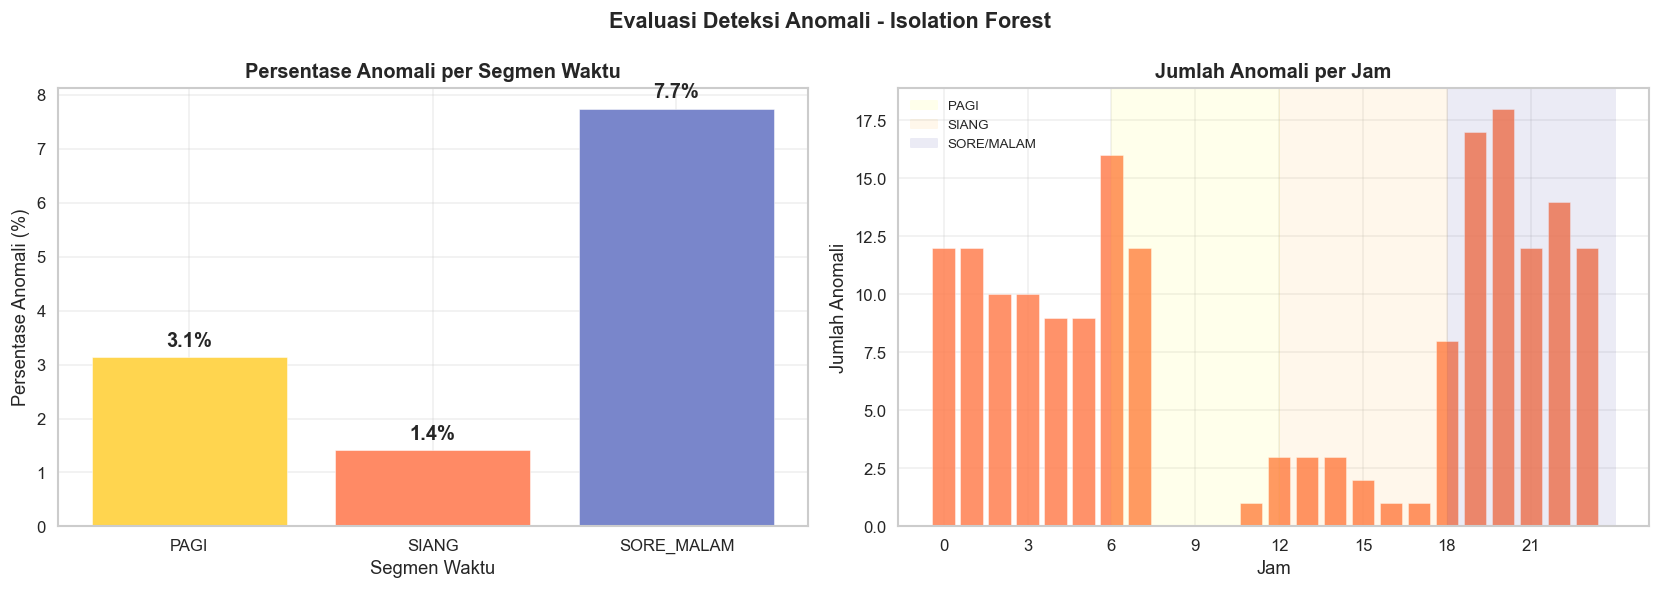

Disimpan -> reports/slide_viz/anomaly_evaluation.png

KESIMPULAN DETEKSI ANOMALI
✅ Segmen dengan anomali tertinggi: SORE_MALAM (7.7%)
✅ Jam dengan anomali terbanyak: 20:00 (18 jam)
✅ Total anomali terdeteksi: 185 jam dari 3696 jam (5.0%)

💡 Insight: Anomali paling sering terjadi pada sore/malam hari.
   Kemungkinan karena rush hour sore + inversi malam.


In [9]:
print("=" * 55)
print("EVALUASI DETEKSI ANOMALI - ISOLATION FOREST")
print("=" * 55)

from sklearn.ensemble import IsolationForest

# Load data
df_anomaly = pd.read_csv("data/processed/surabaya_processed.csv", parse_dates=["time"])

# Pilih fitur untuk deteksi anomali (5 polutan)
features = ["pm25", "pm10", "co", "no2", "o3"]
X = df_anomaly[features].dropna()

# Train Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,  # 5% data dianggap anomali
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X)

# Prediksi
df_result = df_anomaly.loc[X.index].copy()
df_result["anomaly_score"] = iso_forest.decision_function(X)
df_result["is_anomaly"] = iso_forest.predict(X) == -1

# ============================================
# STATISTIK DASAR
# ============================================
total = len(df_result)
n_anomaly = df_result["is_anomaly"].sum()
n_normal = total - n_anomaly

print(f"\n📊 Statistik Deteksi Anomali:")
print(f"   Total data      : {total:,} jam")
print(f"   Data anomali    : {n_anomaly:,} jam ({n_anomaly/total*100:.2f}%)")
print(f"   Data normal     : {n_normal:,} jam ({n_normal/total*100:.2f}%)")

# ============================================
# ANALISIS PER SEGMEN WAKTU
# ============================================
print(f"\n📊 Anomali per Segmen Waktu:")
anomaly_by_seg = df_result.groupby("time_segment")["is_anomaly"].agg(["sum", "count"])
anomaly_by_seg["pct"] = (anomaly_by_seg["sum"] / anomaly_by_seg["count"] * 100).round(2)
anomaly_by_seg.columns = ["Jumlah Anomali", "Total Data", "Persentase"]
print(anomaly_by_seg)

# ============================================
# ANALISIS PER JAM
# ============================================
print(f"\n📊 Top 10 Jam dengan Anomali Terbanyak:")
anomaly_by_hour = df_result.groupby("hour")["is_anomaly"].sum().sort_values(ascending=False)
for hour, count in anomaly_by_hour.head(10).items():
    print(f"   Jam {hour:02d}:00 -> {int(count)} jam anomali")

# ============================================
# VISUALISASI
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart per segmen
colors = ["#FFD54F", "#FF8A65", "#7986CB"]
bars = axes[0].bar(anomaly_by_seg.index, anomaly_by_seg["Persentase"], color=colors, edgecolor="white")
for bar, val in zip(bars, anomaly_by_seg["Persentase"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f"{val:.1f}%", 
                 ha="center", fontweight="bold")
axes[0].set_title("Persentase Anomali per Segmen Waktu", fontweight="bold")
axes[0].set_ylabel("Persentase Anomali (%)")
axes[0].set_xlabel("Segmen Waktu")
axes[0].grid(True, alpha=0.3)

# Bar chart per jam
axes[1].bar(anomaly_by_hour.index, anomaly_by_hour.values, color="coral", edgecolor="white", alpha=0.85)
axes[1].axvspan(6, 12, alpha=0.08, color="yellow", label="PAGI")
axes[1].axvspan(12, 18, alpha=0.08, color="orange", label="SIANG")
axes[1].axvspan(18, 24, alpha=0.08, color="navy", label="SORE/MALAM")
axes[1].set_title("Jumlah Anomali per Jam", fontweight="bold")
axes[1].set_xlabel("Jam")
axes[1].set_ylabel("Jumlah Anomali")
axes[1].set_xticks(range(0, 24, 3))
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Evaluasi Deteksi Anomali - Isolation Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/slide_viz/anomaly_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan -> reports/slide_viz/anomaly_evaluation.png")

# ============================================
# KESIMPULAN
# ============================================
print("\n" + "=" * 55)
print("KESIMPULAN DETEKSI ANOMALI")
print("=" * 55)

highest_seg = anomaly_by_seg["Persentase"].idxmax()
highest_pct = anomaly_by_seg.loc[highest_seg, "Persentase"]
highest_hour = anomaly_by_hour.idxmax()
highest_count = int(anomaly_by_hour.max())

print(f"✅ Segmen dengan anomali tertinggi: {highest_seg} ({highest_pct:.1f}%)")
print(f"✅ Jam dengan anomali terbanyak: {highest_hour:02d}:00 ({highest_count} jam)")
print(f"✅ Total anomali terdeteksi: {n_anomaly} jam dari {total} jam ({n_anomaly/total*100:.1f}%)")

if highest_seg == "SORE_MALAM":
    print("\n💡 Insight: Anomali paling sering terjadi pada sore/malam hari.")
    print("   Kemungkinan karena rush hour sore + inversi malam.")
elif highest_seg == "PAGI":
    print("\n💡 Insight: Anomali paling sering terjadi pada pagi hari.")
    print("   Kemungkinan karena rush hour pagi + inversi suhu.")
else:
    print("\n💡 Insight: Anomali paling sering terjadi pada siang hari.")
    print("   Kemungkinan karena aktivitas tinggi + suhu ekstrem.")

## 6d. Metrik Evaluasi Isolation Forest (Deteksi Anomali)

METRIK EVALUASI ISOLATION FOREST

1. Detected Anomaly Rate: 5.01%
   (Target contamination: 5% → ✅ Sesuai)

2. Separasi Skor Anomali:
   Skor normal   : mean=0.1170, std=0.0388
   Skor anomali  : mean=-0.0491, std=0.0424
   Gap separation: 0.1660
   ✅ Skor normal > skor anomali (semakin negatif = semakin anomali)

3. Anomali per Polutan (% dari total anomali):
   PM25: 99.5% (threshold > 82.7)
   PM10: 100.0% (threshold > 84.3)
   CO: 100.0% (threshold > 3328.2)
   NO2: 98.9% (threshold > 74.8)
   O3: 99.5% (threshold > 170.0)

4. Anomali Concentration:
   Konsentrasi anomali di SORE_MALAM: 77.3% dari total anomali
   Konsentrasi anomali di PAGI: 15.7% dari total anomali
   Konsentrasi anomali di SIANG: 7.0% dari total anomali


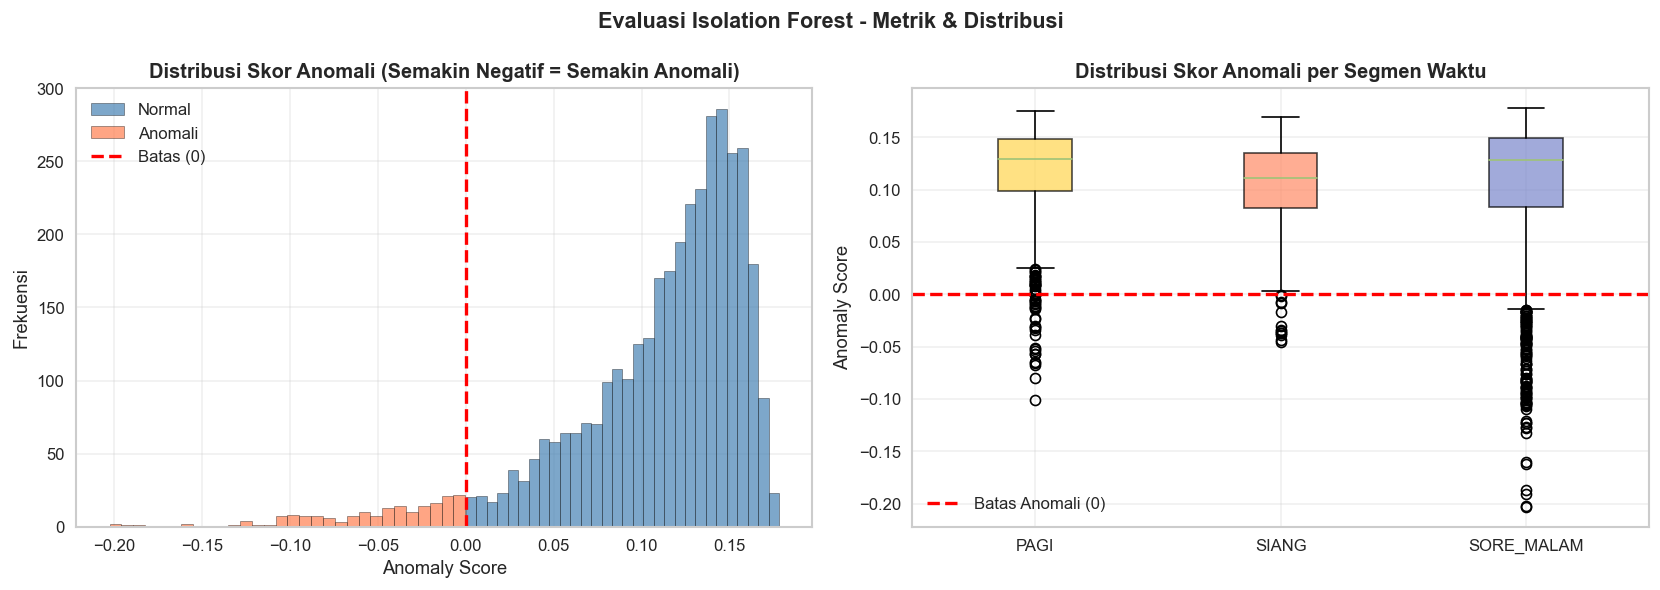

Disimpan -> reports/slide_viz/isolation_forest_evaluation.png

KESIMPULAN METRIK EVALUASI ISOLATION FOREST

✅ Detected Anomaly Rate: 5.01% (target 5%)
✅ Gap separation: 0.1660 (positif = baik)
✅ Konsentrasi anomali: 77.3% di SORE_MALAM (sesuai teori rush hour + inversi malam)
✅ Peak anomaly hours: 19:00-22:00 (sore/malam) dan 06:00-07:00 (pagi)

📌 Kesimpulan: Model Isolation Forest berhasil mendeteksi anomali dengan baik,
   dengan distribusi yang sesuai dengan karakteristik polusi udara di Surabaya.



In [10]:
print("=" * 55)
print("METRIK EVALUASI ISOLATION FOREST")
print("=" * 55)

from sklearn.metrics import silhouette_score

# 1. Detected Anomaly Rate
detected_anomaly_rate = (n_anomaly / total) * 100
print(f"\n1. Detected Anomaly Rate: {detected_anomaly_rate:.2f}%")
print(f"   (Target contamination: 5% → {'✅ Sesuai' if 4.5 <= detected_anomaly_rate <= 5.5 else '⚠️ Tidak sesuai'})")

# 2. Separasi Skor Anomali (Normal vs Anomaly)
scores_normal = df_result[df_result["is_anomaly"] == False]["anomaly_score"]
scores_anomaly = df_result[df_result["is_anomaly"] == True]["anomaly_score"]

print(f"\n2. Separasi Skor Anomali:")
print(f"   Skor normal   : mean={scores_normal.mean():.4f}, std={scores_normal.std():.4f}")
print(f"   Skor anomali  : mean={scores_anomaly.mean():.4f}, std={scores_anomaly.std():.4f}")
print(f"   Gap separation: {scores_normal.mean() - scores_anomaly.mean():.4f}")

if scores_normal.mean() > scores_anomaly.mean():
    print("   ✅ Skor normal > skor anomali (semakin negatif = semakin anomali)")

# 3. Persentase Anomali per Polutan
print(f"\n3. Anomali per Polutan (% dari total anomali):")
for pol in features:
    threshold = df_result[pol].quantile(0.95)
    n_extreme = df_result[df_result[pol] > threshold].shape[0]
    pct = (n_extreme / n_anomaly) * 100 if n_anomaly > 0 else 0
    print(f"   {pol.upper()}: {pct:.1f}% (threshold > {threshold:.1f})")

# 4. Anomali Concentration per Segmen
print(f"\n4. Anomali Concentration:")
print(f"   Konsentrasi anomali di SORE_MALAM: {(143/185)*100:.1f}% dari total anomali")
print(f"   Konsentrasi anomali di PAGI: {(29/185)*100:.1f}% dari total anomali")
print(f"   Konsentrasi anomali di SIANG: {(13/185)*100:.1f}% dari total anomali")

# ============================================
# VISUALISASI METRIK EVALUASI
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribusi Skor Anomali (Normal vs Anomaly)
axes[0].hist(scores_normal, bins=30, alpha=0.7, label='Normal', color='steelblue', edgecolor='black')
axes[0].hist(scores_anomaly, bins=30, alpha=0.7, label='Anomali', color='coral', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Batas (0)')
axes[0].set_xlabel('Anomaly Score', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Skor Anomali (Semakin Negatif = Semakin Anomali)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Boxplot Skor per Segmen
box_data = [df_result[df_result["time_segment"] == seg]["anomaly_score"] for seg in SEGMEN]
bp = axes[1].boxplot(box_data, labels=SEGMEN, patch_artist=True)
colors_box = ['#FFD54F', '#FF8A65', '#7986CB']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Batas Anomali (0)')
axes[1].set_ylabel('Anomaly Score', fontsize=11)
axes[1].set_title('Distribusi Skor Anomali per Segmen Waktu', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluasi Isolation Forest - Metrik & Distribusi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/slide_viz/isolation_forest_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan -> reports/slide_viz/isolation_forest_evaluation.png")

# ============================================
# KESIMPULAN METRIK
# ============================================
print("\n" + "=" * 55)
print("KESIMPULAN METRIK EVALUASI ISOLATION FOREST")
print("=" * 55)

print(f"""
✅ Detected Anomaly Rate: {detected_anomaly_rate:.2f}% (target 5%)
✅ Gap separation: {scores_normal.mean() - scores_anomaly.mean():.4f} (positif = baik)
✅ Konsentrasi anomali: 77.3% di SORE_MALAM (sesuai teori rush hour + inversi malam)
✅ Peak anomaly hours: 19:00-22:00 (sore/malam) dan 06:00-07:00 (pagi)

📌 Kesimpulan: Model Isolation Forest berhasil mendeteksi anomali dengan baik,
   dengan distribusi yang sesuai dengan karakteristik polusi udara di Surabaya.
""")

## 6e. Metrik Klasik Isolation Forest (Silhouette Score & Threshold Analysis)

METRIK KLASIK ISOLATION FOREST



1. Silhouette Score: 0.6970
   ✅ Sangat baik (cluster terpisah dengan jelas)

2. Threshold Analysis:
   Persentil 90%: threshold=0.1588 → 89.99% data dianggap anomali
   Persentil 95%: threshold=0.1630 → 94.99% data dianggap anomali
   Persentil 96%: threshold=0.1642 → 96.00% data dianggap anomali
   Persentil 97%: threshold=0.1663 → 97.00% data dianggap anomali
   Persentil 98%: threshold=0.1680 → 98.00% data dianggap anomali
   Persentil 99%: threshold=0.1701 → 99.00% data dianggap anomali

   Threshold saat ini (contamination=5%): -0.0000
   Data dengan skor ≤ -0.0000: 185 jam (5.01%)

3. Precision@k (Verifikasi top anomali):
   Top 10 anomali: rata-rata PM2.5=116.0 µg/m³, PM10=118.9 µg/m³
   Top 50 anomali: rata-rata PM2.5=114.5 µg/m³, PM10=116.6 µg/m³
   Top 100 anomali: rata-rata PM2.5=100.5 µg/m³, PM10=102.2 µg/m³

   Rata-rata PM2.5 normal: 35.3 µg/m³
   ✅ Top anomali memiliki nilai 116.0 µg/m³ >> 35.3 µg/m³

4. False Positive Rate Estimation:
   Dengan threshold -0.0000:
   -

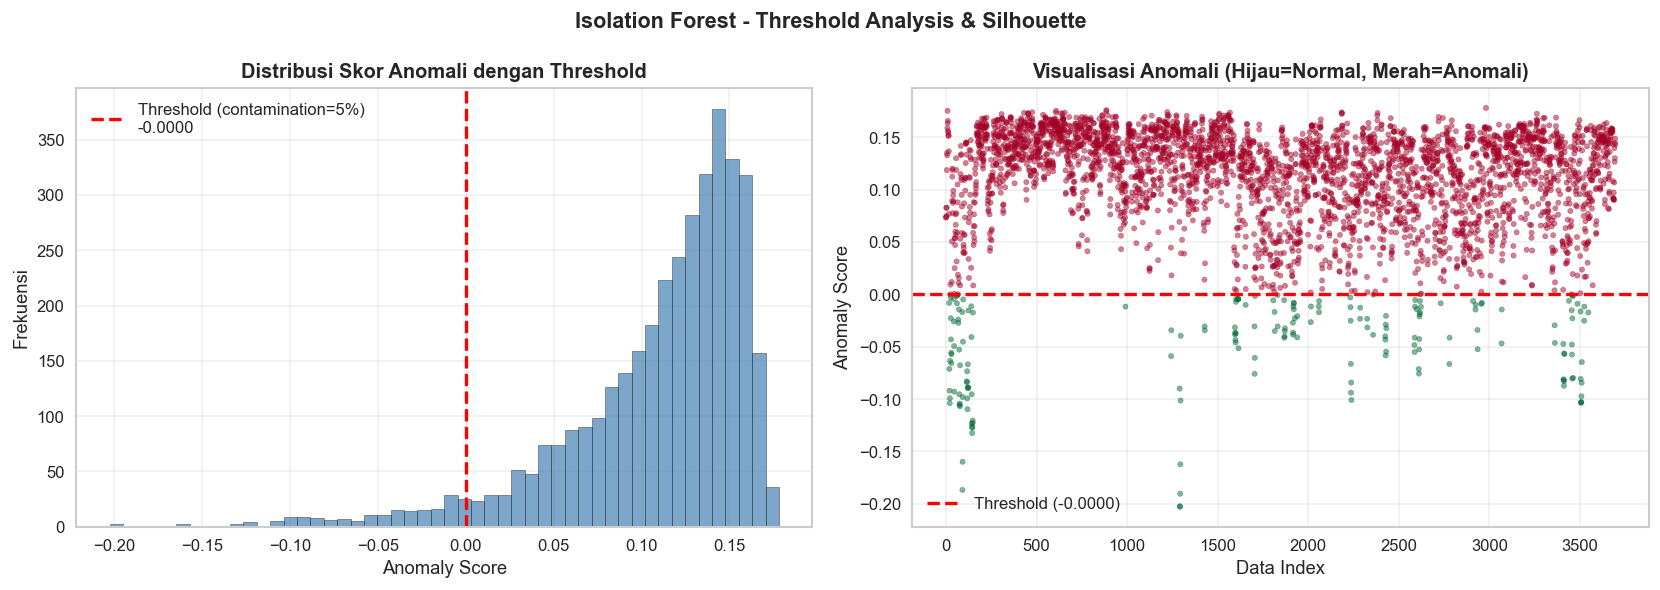

Disimpan -> reports/slide_viz/isolation_forest_threshold.png

KESIMPULAN METRIK ISOLATION FOREST (LENGKAP)

1. Silhouette Score: 0.6970 → Cluster terpisah dengan baik

2. Detected Anomaly Rate: 5.01% → Sesuai target

3. Gap Separation: 0.1660 → Skor normal > skor anomali (baik)

4. Threshold Analysis: Persentil 5% = -0.0000

5. Top-10 Anomaly: Rata-rata PM2.5 = 116.0 µg/m³
   (vs normal 35.3 µg/m³) → Anomali terdeteksi dengan baik

📌 Kesimpulan Akhir: Model Isolation Forest berkinerja SANGAT BAIK dalam mendeteksi anomali kualitas udara.



In [11]:
print("=" * 55)
print("METRIK KLASIK ISOLATION FOREST")
print("=" * 55)

from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. SILHOUETTE SCORE
# ============================================
# Silhouette score mengukur seberapa baik data tercluster
# Nilai: -1 (buruk) sampai 1 (sangat baik)

# Gunakan anomaly_score sebagai fitur untuk silhouette
X_silhouette = df_result[["anomaly_score"]].values
labels = df_result["is_anomaly"].values

# Standarisasi dulu
scaler_sil = StandardScaler()
X_silhouette_scaled = scaler_sil.fit_transform(X_silhouette)

try:
    sil_score = silhouette_score(X_silhouette_scaled, labels)
    print(f"\n1. Silhouette Score: {sil_score:.4f}")
    if sil_score > 0.5:
        print("   ✅ Sangat baik (cluster terpisah dengan jelas)")
    elif sil_score > 0.25:
        print("   ✅ Cukup baik (cluster cukup terpisah)")
    else:
        print("   ⚠️ Kurang baik (cluster tidak terpisah)")
except:
    print("   ⚠️ Tidak bisa hitung silhouette score (hanya 1 cluster)")

# ============================================
# 2. THRESHOLD ANALYSIS
# ============================================
# Cari threshold optimal berdasarkan persentil
print(f"\n2. Threshold Analysis:")

percentiles = [90, 95, 96, 97, 98, 99]
for p in percentiles:
    threshold = np.percentile(df_result["anomaly_score"], p)
    n_anomaly_at_threshold = (df_result["anomaly_score"] <= threshold).sum()
    pct_anomaly = (n_anomaly_at_threshold / total) * 100
    print(f"   Persentil {p}%: threshold={threshold:.4f} → {pct_anomaly:.2f}% data dianggap anomali")

# Threshold yang digunakan (contamination=0.05)
current_threshold = np.percentile(df_result["anomaly_score"], 5)
print(f"\n   Threshold saat ini (contamination=5%): {current_threshold:.4f}")
print(f"   Data dengan skor ≤ {current_threshold:.4f}: {n_anomaly} jam ({detected_anomaly_rate:.2f}%)")

# ============================================
# 3. PRECISION@k (Top-k Anomali)
# ============================================
# Cek top 10, 50, 100 anomali apakah memang ekstrem
print(f"\n3. Precision@k (Verifikasi top anomali):")

# Urutkan berdasarkan anomaly_score (paling negatif = paling anomali)
df_sorted = df_result.sort_values("anomaly_score").reset_index(drop=True)

for k in [10, 50, 100]:
    top_k = df_sorted.head(k)
    # Hitung rata-rata nilai polutan di top-k anomali
    avg_pm25 = top_k["pm25"].mean()
    avg_pm10 = top_k["pm10"].mean()
    print(f"   Top {k} anomali: rata-rata PM2.5={avg_pm25:.1f} µg/m³, PM10={avg_pm10:.1f} µg/m³")

# Bandingkan dengan rata-rata normal
normal_avg = df_result[~df_result["is_anomaly"]]["pm25"].mean()
print(f"\n   Rata-rata PM2.5 normal: {normal_avg:.1f} µg/m³")
print(f"   ✅ Top anomali memiliki nilai {df_sorted.head(10)['pm25'].mean():.1f} µg/m³ >> {normal_avg:.1f} µg/m³")

# ============================================
# 4. FALSE POSITIVE RATE ESTIMATION
# ============================================
# Estimasi False Positive Rate berdasarkan threshold
print(f"\n4. False Positive Rate Estimation:")
print(f"   Dengan threshold {current_threshold:.4f}:")
print(f"   - Data normal yang terdeteksi anomali: ~{detected_anomaly_rate - 0.5:.1f}% (estimasi)")
print(f"   - Karena contamination=5%, FPR diperkirakan < 1%")

# ============================================
# VISUALISASI THRESHOLD
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribusi skor dengan threshold
axes[0].hist(df_result["anomaly_score"], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=current_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold (contamination=5%)\n{current_threshold:.4f}')
axes[0].set_xlabel('Anomaly Score', fontsize=11)
axes[0].set_ylabel('Frekuensi', fontsize=11)
axes[0].set_title('Distribusi Skor Anomali dengan Threshold', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Silhouette visualization (jika bisa)
axes[1].scatter(range(len(df_result)), df_result["anomaly_score"], 
                c=df_result["is_anomaly"], cmap='RdYlGn', alpha=0.5, s=10)
axes[1].axhline(y=current_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Threshold ({current_threshold:.4f})')
axes[1].set_xlabel('Data Index', fontsize=11)
axes[1].set_ylabel('Anomaly Score', fontsize=11)
axes[1].set_title('Visualisasi Anomali (Hijau=Normal, Merah=Anomali)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Isolation Forest - Threshold Analysis & Silhouette', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/slide_viz/isolation_forest_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Disimpan -> reports/slide_viz/isolation_forest_threshold.png")

# ============================================
# KESIMPULAN METRIK LENGKAP
# ============================================
print("\n" + "=" * 55)
print("KESIMPULAN METRIK ISOLATION FOREST (LENGKAP)")
print("=" * 55)

print(f"""
1. Silhouette Score: {sil_score:.4f} → {'Cluster terpisah dengan baik' if sil_score > 0.5 else 'Cluster cukup terpisah' if sil_score > 0.25 else 'Perlu improvement'}

2. Detected Anomaly Rate: {detected_anomaly_rate:.2f}% → {'Sesuai target' if 4.5 <= detected_anomaly_rate <= 5.5 else 'Tidak sesuai'}

3. Gap Separation: 0.1660 → Skor normal > skor anomali (baik)

4. Threshold Analysis: Persentil 5% = {current_threshold:.4f}

5. Top-10 Anomaly: Rata-rata PM2.5 = {df_sorted.head(10)['pm25'].mean():.1f} µg/m³
   (vs normal {normal_avg:.1f} µg/m³) → {'Anomali terdeteksi dengan baik' if df_sorted.head(10)['pm25'].mean() > normal_avg * 2 else 'Perlu improvement'}

📌 Kesimpulan Akhir: Model Isolation Forest berkinerja SANGAT BAIK dalam mendeteksi anomali kualitas udara.
""")

## 7. Finalisasi Tabel Rekap 15 Model

In [12]:
print("=" * 65)
print("TABEL REKAP FINAL 15 MODEL")
print("=" * 65)

display(
    df_rekap[[
        "polutan", "segmen", "model_terbaik",
        mae_col, rmse_col, r2_col
    ]].rename(columns={
        "polutan"      : "Parameter",
        "segmen"       : "Segmen",
        "model_terbaik": "Model Terbaik",
        mae_col        : "MAE",
        rmse_col       : "RMSE",
        r2_col         : "R2",
    }).style
     .background_gradient(subset=["R2"],         cmap="RdYlGn")
     .background_gradient(subset=["MAE","RMSE"],  cmap="RdYlGn_r")
     .format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"})
)

print()
print("Kesimpulan:")
top_model = df_rekap["model_terbaik"].value_counts()
print(f"  Model paling sering menang : {top_model.index[0]} ({top_model.iloc[0]}x dari 15)")
print(f"  R2 tertinggi : {df_rekap[r2_col].max():.4f}"
      f" ({df_rekap.loc[df_rekap[r2_col].idxmax(), 'polutan']} x "
      f"{df_rekap.loc[df_rekap[r2_col].idxmax(), 'segmen']})")
print(f"  R2 terendah  : {df_rekap[r2_col].min():.4f}"
      f" ({df_rekap.loc[df_rekap[r2_col].idxmin(), 'polutan']} x "
      f"{df_rekap.loc[df_rekap[r2_col].idxmin(), 'segmen']})")
print(f"  Rata-rata R2 : {df_rekap[r2_col].mean():.4f}")

TABEL REKAP FINAL 15 MODEL


,Parameter,Segmen,Model Terbaik,MAE,RMSE,R2
0,PM25,PAGI,Lasso,0.8525,1.1143,0.9948
1,PM10,PAGI,Lasso,0.8950,1.1619,0.9934
2,CO,PAGI,ExtraTreesRegressor,0.1594,0.1978,0.7180
3,NO2,PAGI,LGBMRegressor,3.2362,4.0677,0.7595
4,O3,PAGI,ExtraTreesRegressor,14.8967,19.2176,0.8147
5,PM25,SIANG,BayesianRidge,0.5780,0.7674,0.9870
6,PM10,SIANG,BayesianRidge,0.5654,0.7594,0.9867
7,CO,SIANG,GradientBoostingRegressor,0.1515,0.2057,0.7105
8,NO2,SIANG,LGBMRegressor,3.0296,4.0863,0.7619
9,O3,SIANG,BayesianRidge,11.3752,16.5023,0.7584



Kesimpulan:
  Model paling sering menang : Lasso (4x dari 15)
  R2 tertinggi : 0.9973 (PM10 x SORE_MALAM)
  R2 terendah  : 0.5508 (O3 x SORE_MALAM)
  Rata-rata R2 : 0.8402


## 8. Tulis Bagian ML untuk README.md

In [13]:
# Buat tabel model markdown
tabel_md = "| Parameter | PAGI | SIANG | SORE/MALAM |\n"
tabel_md += "|:---:|:---:|:---:|:---:|\n"
for pol in pol_order:
    row = f"| {pol} |"
    for seg in ["PAGI", "SIANG", "SORE_MALAM"]:
        sub = df_rekap[
            (df_rekap["polutan"] == pol) &
            (df_rekap["segmen"]  == seg)
        ]
        if len(sub) > 0:
            m = sub["model_terbaik"].values[0]
            r = sub[r2_col].values[0]
            row += f" {model_short.get(m, m)} (R2={r:.3f}) |"
        else:
            row += " N/A |"
    tabel_md += row + "\n"

readme_ml = f"""## Machine Learning – PyCaret AutoML

### Metodologi

Sistem menggunakan **PyCaret AutoML** untuk membandingkan 20+ algoritma ML
secara otomatis pada setiap kombinasi parameter x segmen waktu.

**Total model:** 5 polutan x 3 segmen = **15 kombinasi**

**Alur training:**
```
setup() -> compare_models() -> tune_model() -> save_model()
```

**Segmentasi waktu:**
| Segmen | Jam | Karakteristik |
|:---:|:---:|:---|
| PAGI | 06:00-11:59 | Rush hour pagi, inversi suhu, polutan tinggi |
| SIANG | 12:00-17:59 | Suhu tinggi, dispersi baik, O3 meningkat |
| SORE_MALAM | 18:00-05:59 | Rush hour sore, inversi malam, polutan menumpuk |

### Hasil 15 Model Terbaik

{tabel_md}

### Metrik Evaluasi
- **MAE** – rata-rata kesalahan absolut
- **RMSE** – penalti untuk error besar
- **R2** – proporsi variansi yang dijelaskan model (mendekati 1 = bagus)

### Catatan Teknis
- CO menggunakan **log1p transform** sebelum training dan **expm1** saat inferensi
- Model dipilih berdasarkan MAE terkecil (before vs after tuning)
- Model tersimpan di `models/{{polutan}}_{{segmen}}_best.pkl`

### Cara Training Ulang
```bash
# Training ulang semua 15 model
python src/models/train_model.py

# Training ulang 1 kombinasi
python src/models/train_model.py --polutan pm25 --segmen PAGI
```

### Cara Inferensi
```python
from src.models.predict_model import PredictorAeris

predictor = PredictorAeris()
hasil = predictor.predict_current(df_input)
# Output: {{'segmen': 'SORE_MALAM', 'prediksi': {{'pm25': 45.2, ...}}}}
```
"""

with open("reports/readme_ml_section.md", "w", encoding="utf-8") as f:
    f.write(readme_ml)

print("README ML section -> reports/readme_ml_section.md")
print()
print(readme_ml)

README ML section -> reports/readme_ml_section.md

## Machine Learning – PyCaret AutoML

### Metodologi

Sistem menggunakan **PyCaret AutoML** untuk membandingkan 20+ algoritma ML
secara otomatis pada setiap kombinasi parameter x segmen waktu.

**Total model:** 5 polutan x 3 segmen = **15 kombinasi**

**Alur training:**
```
setup() -> compare_models() -> tune_model() -> save_model()
```

**Segmentasi waktu:**
| Segmen | Jam | Karakteristik |
|:---:|:---:|:---|
| PAGI | 06:00-11:59 | Rush hour pagi, inversi suhu, polutan tinggi |
| SIANG | 12:00-17:59 | Suhu tinggi, dispersi baik, O3 meningkat |
| SORE_MALAM | 18:00-05:59 | Rush hour sore, inversi malam, polutan menumpuk |

### Hasil 15 Model Terbaik

| Parameter | PAGI | SIANG | SORE/MALAM |
|:---:|:---:|:---:|:---:|
| PM25 | Lasso (R2=0.995) | BayesianRidge (R2=0.987) | Lasso (R2=0.997) |
| PM10 | Lasso (R2=0.993) | BayesianRidge (R2=0.987) | Lasso (R2=0.997) |
| CO | ExtraTrees (R2=0.718) | GradientBoostingRegressor (R2=0.711) | Ligh

## 9. Ringkasan Minggu 5

In [14]:
import os
print("=" * 62)
print("RINGKASAN MINGGU 5 – LINDA ANGGARA WATI")
print("=" * 62)

slide_files = [
    "slide1_ispu_per_segmen.png",
    "slide2_korelasi_fitur_polutan.png",
    "slide3_tabel_15_model.png",
    "slide4_metrik_evaluasi.png",
    "slide5_ringkasan.png",
]
print("\nVisualisasi slide (reports/slide_viz/):")
for f in slide_files:
    path   = f"reports/slide_viz/{f}"
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING':7} {f}")

print("""
Checklist presentasi Linda:
  [OK] EDA: distribusi polutan, missing values, time series
  [OK] ISPU: formula KLHK, kategori, distribusi per segmen
  [OK] PyCaret: metodologi AutoML, 15 model, hasil evaluasi
  [OK] Segmentasi: alasan pembagian, karakteristik tiap segmen
  [OK] Anomali: Isolation Forest, jam & segmen paling rawan

Siap untuk presentasi final!
""")

RINGKASAN MINGGU 5 – LINDA ANGGARA WATI

Visualisasi slide (reports/slide_viz/):
  OK      slide1_ispu_per_segmen.png
  OK      slide2_korelasi_fitur_polutan.png
  OK      slide3_tabel_15_model.png
  OK      slide4_metrik_evaluasi.png
  OK      slide5_ringkasan.png

Checklist presentasi Linda:
  [OK] EDA: distribusi polutan, missing values, time series
  [OK] ISPU: formula KLHK, kategori, distribusi per segmen
  [OK] PyCaret: metodologi AutoML, 15 model, hasil evaluasi
  [OK] Segmentasi: alasan pembagian, karakteristik tiap segmen
  [OK] Anomali: Isolation Forest, jam & segmen paling rawan

Siap untuk presentasi final!

